# Fairness - MLP em CuPy no Adult Income

Este notebook testa uma MLP implementada do zero usando **CuPy/GPU** com um conjunto reduzido de entradas para o Adult Income.

Configuração pedida:

- Remove `sex` das entradas.
- Remove `race` das entradas.
- Remove `native_country` das entradas.
- Remove `occupation` das entradas.
- Remove `relationship` das entradas.
- `marital_status` vira somente `is_married_civ_spouse`.
- `education` vira apenas quatro indicadores: `Prof-school`, `Doctorate`, `Masters`, `Bachelors`.
- Mantém `education_num`.
- `fnlwgt` é usado como **peso amostral**, não como entrada.
- `age`, `capital_gain`, `capital_loss` e `hours_per_week` são usados em faixas.
- `capital_gain` e `capital_loss` têm apenas uma categoria para zero, sem representar zero duas vezes.

Mesmo removendo `sex` e `race` das entradas, eles continuam guardados para avaliação de fairness.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Este notebook foi configurado para CuPy/GPU. Instale uma versão compatível com sua CUDA, "
        "por exemplo: python -m pip install cupy-cuda12x"
    ) from exc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)
cp.random.seed(SEED)

xp = cp
print('Backend: CuPy/GPU')
print('CuPy:', cp.__version__)
try:
    print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
except Exception as exc:
    print('GPU detectada, mas não foi possível ler o nome:', exc)

Backend: CuPy/GPU
CuPy: 14.0.1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Carregamento do Adult Income

Usamos o split oficial da UCI: `adult.data` para treino e `adult.test` para teste.

In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

URLS = {
    'adult.data': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    'adult.test': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
    'adult.names': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names',
}

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

NUMERIC_RAW = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
TARGET_COL = 'income'

for name, url in URLS.items():
    file_path = DATA_DIR / name
    if not file_path.exists():
        print(f'Baixando {name}...')
        urlretrieve(url, file_path)


def read_adult(path, is_test=False):
    df = pd.read_csv(
        path,
        names=COLUMNS,
        sep=',',
        skipinitialspace=True,
        skiprows=1 if is_test else 0,
        keep_default_na=False,
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    df[TARGET_COL] = df[TARGET_COL].str.replace('.', '', regex=False)
    for col in NUMERIC_RAW:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

train_df = read_adult(DATA_DIR / 'adult.data')
test_df = read_adult(DATA_DIR / 'adult.test', is_test=True)

print('Treino:', train_df.shape)
print('Teste :', test_df.shape)
train_df.head()

Treino: (32561, 15)
Teste : (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Engenharia de features reduzida

As entradas da rede são deliberadamente reduzidas para testar fairness e proxies.

`fnlwgt` não entra em `X`: ele vira `sample_weight` no treino.

In [4]:
EDUCATION_LEVELS = ['Prof-school', 'Doctorate', 'Masters', 'Bachelors']

AGE_LABELS = ['age_17_25', 'age_26_35', 'age_36_45', 'age_46_55', 'age_56_65', 'age_66_plus']
HOURS_LABELS = ['hours_1_30', 'hours_31_40', 'hours_41_50', 'hours_51_60', 'hours_61_plus']
GAIN_LABELS = ['capital_gain_0', 'capital_gain_1_5k', 'capital_gain_5k_10k', 'capital_gain_10k_plus']
LOSS_LABELS = ['capital_loss_0', 'capital_loss_1_1k', 'capital_loss_1k_2k', 'capital_loss_2k_plus']


def make_reduced_features(df, stats=None, fit=False):
    out = pd.DataFrame(index=df.index)

    # Estado civil reduzido.
    out['is_married_civ_spouse'] = (df['marital_status'] == 'Married-civ-spouse').astype(np.float32)

    # Educação reduzida a níveis superiores específicos.
    for level in EDUCATION_LEVELS:
        safe_name = level.lower().replace('-', '_')
        out[f'education_{safe_name}'] = (df['education'] == level).astype(np.float32)

    # education_num permanece como variável numérica padronizada.
    if fit:
        stats = {
            'education_num_mean': float(df['education_num'].mean()),
            'education_num_std': float(df['education_num'].std(ddof=0) or 1.0),
        }
    out['education_num_z'] = (
        (df['education_num'] - stats['education_num_mean']) / stats['education_num_std']
    ).astype(np.float32)

    # Faixas de idade.
    age_bins = pd.cut(
        df['age'],
        bins=[16, 25, 35, 45, 55, 65, 100],
        labels=AGE_LABELS,
        include_lowest=True,
    )
    for label in AGE_LABELS:
        out[label] = (age_bins.astype(str) == label).astype(np.float32)

    # Faixas de horas por semana.
    hours_bins = pd.cut(
        df['hours_per_week'],
        bins=[0, 30, 40, 50, 60, 100],
        labels=HOURS_LABELS,
        include_lowest=True,
    )
    for label in HOURS_LABELS:
        out[label] = (hours_bins.astype(str) == label).astype(np.float32)

    # Capital gain: uma única categoria para zero.
    gain_bins = pd.cut(
        df['capital_gain'],
        bins=[-1, 0, 5000, 10000, np.inf],
        labels=GAIN_LABELS,
        include_lowest=True,
    )
    for label in GAIN_LABELS:
        out[label] = (gain_bins.astype(str) == label).astype(np.float32)

    # Capital loss: uma única categoria para zero.
    loss_bins = pd.cut(
        df['capital_loss'],
        bins=[-1, 0, 1000, 2000, np.inf],
        labels=LOSS_LABELS,
        include_lowest=True,
    )
    for label in LOSS_LABELS:
        out[label] = (loss_bins.astype(str) == label).astype(np.float32)

    return out, stats


def encode_target(series):
    return (series.astype(str).str.strip() == '>50K').astype(np.int64).to_numpy()

X_train_df, feature_stats = make_reduced_features(train_df, fit=True)
X_test_df, _ = make_reduced_features(test_df, stats=feature_stats, fit=False)

feature_names = X_train_df.columns.to_list()
X_train_np = X_train_df.to_numpy(dtype=np.float32)
X_test_np = X_test_df.to_numpy(dtype=np.float32)
y_train_np = encode_target(train_df[TARGET_COL])
y_test_np = encode_target(test_df[TARGET_COL])

sample_weight_train_np = train_df['fnlwgt'].to_numpy(dtype=np.float32)
sample_weight_train_np = sample_weight_train_np / sample_weight_train_np.mean()
sample_weight_train_np = np.clip(sample_weight_train_np, 0.05, 5.0).astype(np.float32)

sample_weight_test_np = test_df['fnlwgt'].to_numpy(dtype=np.float32)
sample_weight_test_np = sample_weight_test_np / sample_weight_test_np.mean()
sample_weight_test_np = np.clip(sample_weight_test_np, 0.05, 5.0).astype(np.float32)

sensitive_test = {
    'sex': test_df['sex'].to_numpy(),
    'race': test_df['race'].to_numpy(),
}

print('Features usadas:', len(feature_names))
print(feature_names)
print('X_train:', X_train_np.shape)
print('Peso fnlwgt treino:')
display(pd.Series(sample_weight_train_np).describe())
X_train_df.head()

Features usadas: 25
['is_married_civ_spouse', 'education_prof_school', 'education_doctorate', 'education_masters', 'education_bachelors', 'education_num_z', 'age_17_25', 'age_26_35', 'age_36_45', 'age_46_55', 'age_56_65', 'age_66_plus', 'hours_1_30', 'hours_31_40', 'hours_41_50', 'hours_51_60', 'hours_61_plus', 'capital_gain_0', 'capital_gain_1_5k', 'capital_gain_5k_10k', 'capital_gain_10k_plus', 'capital_loss_0', 'capital_loss_1_1k', 'capital_loss_1k_2k', 'capital_loss_2k_plus']
X_train: (32561, 25)
Peso fnlwgt treino:


count    32561.000000
mean         0.999468
std          0.551492
min          0.064733
25%          0.620866
50%          0.939812
75%          1.249094
max          5.000000
dtype: float64

,is_married_civ_spouse,education_prof_school,education_doctorate,education_masters,education_bachelors,education_num_z,age_17_25,age_26_35,age_36_45,age_46_55,...,hours_51_60,hours_61_plus,capital_gain_0,capital_gain_1_5k,capital_gain_5k_10k,capital_gain_10k_plus,capital_loss_0,capital_loss_1_1k,capital_loss_1k_2k,capital_loss_2k_plus
0,0.0,0.0,0.0,0.0,1.0,1.134739,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.134739,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,-0.420060,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,-1.197459,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,1.134739,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 3. Transferência para GPU

In [5]:
X_train = cp.asarray(X_train_np, dtype=cp.float32)
X_test = cp.asarray(X_test_np, dtype=cp.float32)
y_train = cp.asarray(y_train_np, dtype=cp.int64)
y_test = cp.asarray(y_test_np, dtype=cp.int64)
sample_weight_train = cp.asarray(sample_weight_train_np, dtype=cp.float32)

print(X_train.shape, X_train.dtype)
print(y_train.shape, y_train.dtype)
print(sample_weight_train.shape, sample_weight_train.dtype)

(32561, 25) float32
(32561,) int64
(32561,) float32


## 4. Métricas e fairness

In [6]:
def asnumpy(a):
    return cp.asnumpy(a) if isinstance(a, cp.ndarray) else np.asarray(a)


def classification_metrics_np(y_true, y_pred, sample_weight=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if sample_weight is None:
        sample_weight = np.ones_like(y_true, dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)

    tp = sample_weight[(y_true == 1) & (y_pred == 1)].sum()
    tn = sample_weight[(y_true == 0) & (y_pred == 0)].sum()
    fp = sample_weight[(y_true == 0) & (y_pred == 1)].sum()
    fn = sample_weight[(y_true == 1) & (y_pred == 0)].sum()

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1e-12)
    precision = tp / max(tp + fp, 1e-12)
    recall = tp / max(tp + fn, 1e-12)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    balanced_accuracy = 0.5 * (
        tp / max(tp + fn, 1e-12) + tn / max(tn + fp, 1e-12)
    )
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_accuracy,
        'precision_>50K': precision,
        'recall_>50K': recall,
        'f1_>50K': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def fairness_binary_report(y_pred, sensitive, unprivileged, privileged):
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    unpriv_mask = sensitive == unprivileged
    priv_mask = sensitive == privileged
    rate_unpriv = y_pred[unpriv_mask].mean() if unpriv_mask.any() else np.nan
    rate_priv = y_pred[priv_mask].mean() if priv_mask.any() else np.nan
    return {
        'unprivileged': unprivileged,
        'privileged': privileged,
        'selection_rate_unprivileged': rate_unpriv,
        'selection_rate_privileged': rate_priv,
        'statistical_parity_difference': rate_unpriv - rate_priv,
        'disparate_impact': rate_unpriv / rate_priv if rate_priv > 0 else np.nan,
    }


def selection_rates(y_pred, group_values):
    df = pd.DataFrame({'group': group_values, 'pred_high_income': y_pred})
    return df.groupby('group')['pred_high_income'].agg(['count', 'mean']).sort_values('mean', ascending=False)

## 5. MLP do zero em CuPy

A loss usa `sample_weight_train`, derivado de `fnlwgt`.

In [7]:
def one_hot_cp(y, n_classes=2):
    out = cp.zeros((y.shape[0], n_classes), dtype=cp.float32)
    out[cp.arange(y.shape[0]), y.astype(cp.int64)] = 1.0
    return out


class CuPyMLP:
    def __init__(self, layer_sizes, seed=42, l2=0.0, momentum=0.0):
        self.layer_sizes = list(layer_sizes)
        self.l2 = float(l2)
        self.momentum = float(momentum)
        self.params = []
        self.velocities = []
        rs = np.random.default_rng(seed)
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            if i < len(layer_sizes) - 2:
                W_np = rs.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out)).astype(np.float32)
            else:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                W_np = rs.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)
            b_np = np.zeros((1, fan_out), dtype=np.float32)
            W = cp.asarray(W_np)
            b = cp.asarray(b_np)
            self.params.append({'W': W, 'b': b})
            self.velocities.append({'W': cp.zeros_like(W), 'b': cp.zeros_like(b)})

    def relu(self, Z):
        return cp.maximum(Z, 0)

    def relu_grad(self, Z):
        return (Z > 0).astype(cp.float32)

    def softmax(self, Z):
        Z_shift = Z - cp.max(Z, axis=1, keepdims=True)
        exp_Z = cp.exp(Z_shift)
        return exp_Z / cp.sum(exp_Z, axis=1, keepdims=True)

    def forward(self, X, return_cache=True):
        A = X
        cache = {'A': [A], 'Z': []}
        for i, layer in enumerate(self.params):
            Z = A @ layer['W'] + layer['b']
            cache['Z'].append(Z)
            A = self.relu(Z) if i < len(self.params) - 1 else self.softmax(Z)
            cache['A'].append(A)
        return (A, cache) if return_cache else A

    def loss(self, probs, y, sample_weight=None):
        y_oh = one_hot_cp(y, probs.shape[1])
        per_sample = -cp.sum(y_oh * cp.log(cp.clip(probs, 1e-12, 1.0)), axis=1)
        if sample_weight is None:
            data_loss = cp.mean(per_sample)
        else:
            data_loss = cp.sum(sample_weight * per_sample) / cp.sum(sample_weight)
        if self.l2 > 0:
            l2_loss = sum(cp.sum(layer['W'] ** 2) for layer in self.params)
            data_loss = data_loss + 0.5 * self.l2 * l2_loss
        return data_loss

    def backward(self, cache, y, sample_weight=None):
        probs = cache['A'][-1]
        y_oh = one_hot_cp(y, probs.shape[1])
        dZ = probs - y_oh
        if sample_weight is None:
            dZ = dZ / y.shape[0]
        else:
            dZ = dZ * sample_weight.reshape(-1, 1) / cp.sum(sample_weight)

        grads = [None] * len(self.params)
        for i in reversed(range(len(self.params))):
            A_prev = cache['A'][i]
            dW = A_prev.T @ dZ
            db = cp.sum(dZ, axis=0, keepdims=True)
            if self.l2 > 0:
                dW = dW + self.l2 * self.params[i]['W']
            grads[i] = {'W': dW, 'b': db}
            if i > 0:
                dA_prev = dZ @ self.params[i]['W'].T
                dZ = dA_prev * self.relu_grad(cache['Z'][i - 1])
        return grads

    def step(self, grads, lr):
        for i, grad in enumerate(grads):
            if self.momentum > 0:
                self.velocities[i]['W'] = self.momentum * self.velocities[i]['W'] - lr * grad['W']
                self.velocities[i]['b'] = self.momentum * self.velocities[i]['b'] - lr * grad['b']
                self.params[i]['W'] += self.velocities[i]['W']
                self.params[i]['b'] += self.velocities[i]['b']
            else:
                self.params[i]['W'] -= lr * grad['W']
                self.params[i]['b'] -= lr * grad['b']

    def predict_proba(self, X):
        return self.forward(X, return_cache=False)

    def predict(self, X):
        return cp.argmax(self.predict_proba(X), axis=1)

In [8]:
def train_mlp(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    sample_weight_train=None,
    epochs=50,
    batch_size=512,
    lr=0.03,
    lr_decay=0.02,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    history = []

    for epoch in range(1, epochs + 1):
        indices_np = rng.permutation(n)
        current_lr = lr / (1.0 + lr_decay * (epoch - 1))
        losses = []

        for start in range(0, n, batch_size):
            batch_idx = cp.asarray(indices_np[start:start + batch_size], dtype=cp.int64)
            Xb = X_train[batch_idx]
            yb = y_train[batch_idx]
            wb = sample_weight_train[batch_idx] if sample_weight_train is not None else None

            probs, cache = model.forward(Xb, return_cache=True)
            batch_loss = model.loss(probs, yb, wb)
            grads = model.backward(cache, yb, wb)
            model.step(grads, current_lr)
            losses.append(float(cp.asnumpy(batch_loss)))

        train_pred = asnumpy(model.predict(X_train))
        test_pred = asnumpy(model.predict(X_test))
        train_metrics = classification_metrics_np(asnumpy(y_train), train_pred)
        test_metrics = classification_metrics_np(asnumpy(y_test), test_pred)
        row = {
            'epoch': epoch,
            'lr': current_lr,
            'loss': float(np.mean(losses)),
            'train_accuracy': train_metrics['accuracy'],
            'test_accuracy': test_metrics['accuracy'],
            'train_f1': train_metrics['f1_>50K'],
            'test_f1': test_metrics['f1_>50K'],
        }
        history.append(row)
        if epoch == 1 or epoch % max(1, epochs // 5) == 0 or epoch == epochs:
            print(
                f"epoch {epoch:03d}/{epochs} | loss={row['loss']:.4f} | "
                f"acc_test={row['test_accuracy']:.4f} | f1_test={row['test_f1']:.4f}"
            )
    return pd.DataFrame(history)

## 6. Treino do modelo reduzido ponderado por `fnlwgt`

In [39]:
input_dim = X_train.shape[1]
architecture = [input_dim, 64, 32, 2]
param_count = sum(architecture[i] * architecture[i + 1] + architecture[i + 1] for i in range(len(architecture) - 1))
print('Arquitetura:', architecture)
print('Parâmetros treináveis:', param_count)

model = CuPyMLP(architecture, seed=SEED, l2=1e-4, momentum=0.9)
history = train_mlp(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    sample_weight_train=sample_weight_train,
    epochs=500,
    batch_size=256,
    lr=0.02,
    lr_decay=0.01,
    seed=SEED,
)

Arquitetura: [25, 64, 32, 2]
Parâmetros treináveis: 3810
epoch 001/500 | loss=0.3922 | acc_test=0.8460 | f1_test=0.6211
epoch 100/500 | loss=0.3125 | acc_test=0.8484 | f1_test=0.6452
epoch 200/500 | loss=0.3094 | acc_test=0.8477 | f1_test=0.6555
epoch 300/500 | loss=0.3085 | acc_test=0.8477 | f1_test=0.6412
epoch 400/500 | loss=0.3071 | acc_test=0.8488 | f1_test=0.6546
epoch 500/500 | loss=0.3053 | acc_test=0.8467 | f1_test=0.6550


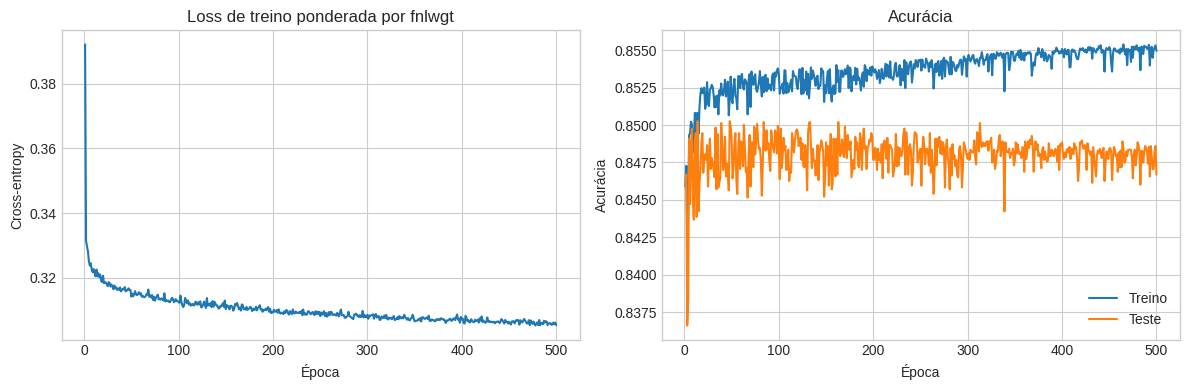

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_title('Loss de treino ponderada por fnlwgt')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-entropy')

axes[1].plot(history['epoch'], history['train_accuracy'], label='Treino')
axes[1].plot(history['epoch'], history['test_accuracy'], label='Teste')
axes[1].set_title('Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Avaliação preditiva e fairness

In [41]:
test_proba = asnumpy(model.predict_proba(X_test))
test_pred = test_proba.argmax(axis=1)

unweighted_metrics = classification_metrics_np(y_test_np, test_pred)
weighted_metrics = classification_metrics_np(y_test_np, test_pred, sample_weight=sample_weight_test_np)

print('Métricas não ponderadas')
display(pd.DataFrame([unweighted_metrics]))
print('Métricas ponderadas por fnlwgt no teste')
display(pd.DataFrame([weighted_metrics]))

print('Taxa de seleção por sex (sex não entra no modelo)')
display(selection_rates(test_pred, sensitive_test['sex']))
print('Taxa de seleção por race (race não entra no modelo)')
display(selection_rates(test_pred, sensitive_test['race']))

fairness_rows = [
    {'attribute': 'sex', **fairness_binary_report(test_pred, sensitive_test['sex'], 'Female', 'Male')},
    {'attribute': 'race', **fairness_binary_report(test_pred, sensitive_test['race'], 'Black', 'White')},
]
fairness_df = pd.DataFrame(fairness_rows)
display(fairness_df)

Métricas não ponderadas


,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K,tp,tn,fp,fn
0,0.846692,0.767009,0.699233,0.615965,0.654963,2369.0,11416.0,1019.0,1477.0


Métricas ponderadas por fnlwgt no teste


,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K,tp,tn,fp,fn
0,0.849082,0.766835,0.709954,0.61089,0.656707,2349.28488,11469.410553,959.78163,1496.392086


Taxa de seleção por sex (sex não entra no modelo)


,count,mean
group,,
Male,10860,0.274678
Female,5421,0.074709


Taxa de seleção por race (race não entra no modelo)


,count,mean
group,,
Asian-Pac-Islander,480,0.277083
White,13946,0.219705
Other,135,0.133333
Amer-Indian-Eskimo,159,0.113208
Black,1561,0.099295


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,sex,Female,Male,0.074709,0.274678,-0.199968,0.271990
1,race,Black,White,0.099295,0.219705,-0.120409,0.451949


## 8. Importância por permutação na MLP reduzida

A permutation importance abaixo embaralha cada feature reduzida e mede a queda de F1.

,feature,base_f1,mean_drop_f1,std_drop_f1
0,is_married_civ_spouse,0.645226,0.164108,0.006275
1,education_num_z,0.645226,0.092808,0.003142
2,age_17_25,0.645226,0.035336,0.001265
3,capital_gain_10k_plus,0.645226,0.025882,0.001816
4,hours_1_30,0.645226,0.021403,0.001511
5,age_46_55,0.645226,0.011768,0.001238
6,education_bachelors,0.645226,0.010098,0.001892
7,capital_loss_1k_2k,0.645226,0.007382,0.001391
8,hours_31_40,0.645226,0.005926,0.000742
9,capital_gain_5k_10k,0.645226,0.005043,0.001377


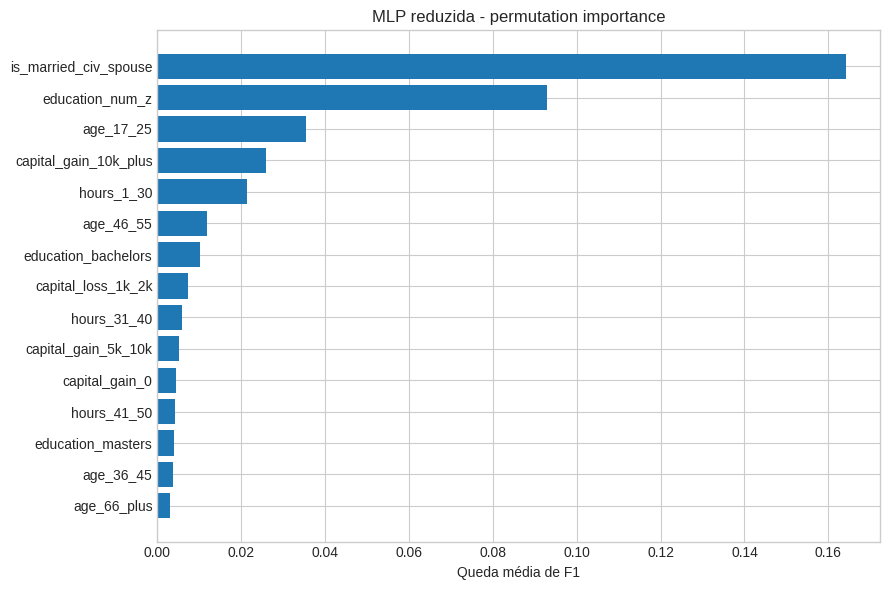

In [12]:
def permutation_importance_mlp(model, X_np, y_np, feature_names, n_repeats=5, seed=42):
    rng = np.random.default_rng(seed)
    X_base = X_np.astype(np.float32)
    base_pred = asnumpy(model.predict(cp.asarray(X_base)))
    base_f1 = classification_metrics_np(y_np, base_pred)['f1_>50K']
    rows = []
    for j, feature in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_base.copy()
            perm = rng.permutation(X_perm.shape[0])
            X_perm[:, j] = X_perm[perm, j]
            pred = asnumpy(model.predict(cp.asarray(X_perm)))
            f1 = classification_metrics_np(y_np, pred)['f1_>50K']
            drops.append(base_f1 - f1)
        rows.append({
            'feature': feature,
            'base_f1': base_f1,
            'mean_drop_f1': float(np.mean(drops)),
            'std_drop_f1': float(np.std(drops)),
        })
    return pd.DataFrame(rows).sort_values('mean_drop_f1', ascending=False).reset_index(drop=True)

mlp_importance = permutation_importance_mlp(model, X_test_np, y_test_np, feature_names, n_repeats=5, seed=SEED)
display(mlp_importance)

fig, ax = plt.subplots(figsize=(9, 6))
top = mlp_importance.head(15).iloc[::-1]
ax.barh(top['feature'], top['mean_drop_f1'])
ax.set_title('MLP reduzida - permutation importance')
ax.set_xlabel('Queda média de F1')
plt.tight_layout()
plt.show()


## 9. Segunda MLP: adicionando `occupation`

Agora treinamos uma segunda rede com a mesma base reduzida, mas adicionando `occupation` em one-hot.

A ideia é comparar:

- **MLP reduzida:** sem `occupation`.
- **MLP + occupation:** inclui `occupation`, mas continua sem `sex`, `race` e `native_country`.

Isso testa se `occupation` melhora desempenho e se também funciona como proxy para disparidades por `sex`/`race`.


In [43]:

def add_occupation_features(base_features_df, train_df, test_df):
    all_occupations = sorted(
        pd.concat([train_df['occupation'], test_df['occupation']], axis=0)
        .replace('?', 'Unknown')
        .astype(str)
        .unique()
        .tolist()
    )

    def transform(df, base_df):
        out = base_df.copy()
        occupation = df['occupation'].replace('?', 'Unknown').astype(str)
        for occ in all_occupations:
            safe = occ.lower().replace('-', '_').replace(' ', '_').replace('?', 'unknown')
            out[f'occupation_{safe}'] = (occupation == occ).astype(np.float32)
        return out

    return transform(train_df, X_train_df), transform(test_df, X_test_df), all_occupations

X_train_occ_df, X_test_occ_df, occupation_categories = add_occupation_features(X_train_df, train_df, test_df)
feature_names_occ = X_train_occ_df.columns.to_list()
X_train_occ_np = X_train_occ_df.to_numpy(dtype=np.float32)
X_test_occ_np = X_test_occ_df.to_numpy(dtype=np.float32)

print('Categorias de occupation:', occupation_categories)
print('Features sem occupation:', X_train_np.shape[1])
print('Features com occupation:', X_train_occ_np.shape[1])
X_train_occ_df.head()


Categorias de occupation: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving', 'Unknown']
Features sem occupation: 25
Features com occupation: 40


,is_married_civ_spouse,education_prof_school,education_doctorate,education_masters,education_bachelors,education_num_z,age_17_25,age_26_35,age_36_45,age_46_55,...,occupation_handlers_cleaners,occupation_machine_op_inspct,occupation_other_service,occupation_priv_house_serv,occupation_prof_specialty,occupation_protective_serv,occupation_sales,occupation_tech_support,occupation_transport_moving,occupation_unknown
0,0.0,0.0,0.0,0.0,1.0,1.134739,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.134739,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,-0.420060,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,-1.197459,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,1.134739,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [44]:

X_train_occ = cp.asarray(X_train_occ_np, dtype=cp.float32)
X_test_occ = cp.asarray(X_test_occ_np, dtype=cp.float32)

input_dim_occ = X_train_occ.shape[1]
architecture_occ = [input_dim_occ, 64, 32, 2]
param_count_occ = sum(architecture_occ[i] * architecture_occ[i + 1] + architecture_occ[i + 1] for i in range(len(architecture_occ) - 1))
print('Arquitetura com occupation:', architecture_occ)
print('Parâmetros treináveis:', param_count_occ)

model_occ = CuPyMLP(architecture_occ, seed=SEED, l2=1e-4, momentum=0.9)
history_occ = train_mlp(
    model_occ,
    X_train_occ,
    y_train,
    X_test_occ,
    y_test,
    sample_weight_train=sample_weight_train,
    epochs=500,
    batch_size=512,
    lr=0.003,
    lr_decay=0.001,
    seed=SEED,
)


Arquitetura com occupation: [40, 64, 32, 2]
Parâmetros treináveis: 4770
epoch 001/500 | loss=0.4962 | acc_test=0.8109 | f1_test=0.4242
epoch 100/500 | loss=0.3090 | acc_test=0.8538 | f1_test=0.6732
epoch 200/500 | loss=0.3044 | acc_test=0.8541 | f1_test=0.6702
epoch 300/500 | loss=0.3023 | acc_test=0.8531 | f1_test=0.6694
epoch 400/500 | loss=0.2997 | acc_test=0.8532 | f1_test=0.6636
epoch 500/500 | loss=0.2971 | acc_test=0.8516 | f1_test=0.6747


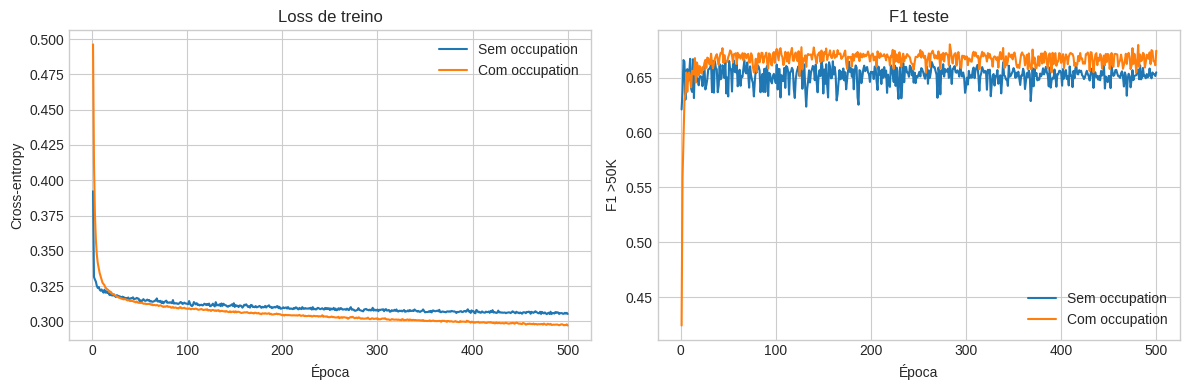

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['epoch'], history['loss'], label='Sem occupation')
axes[0].plot(history_occ['epoch'], history_occ['loss'], label='Com occupation')
axes[0].set_title('Loss de treino')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-entropy')
axes[0].legend()

axes[1].plot(history['epoch'], history['test_f1'], label='Sem occupation')
axes[1].plot(history_occ['epoch'], history_occ['test_f1'], label='Com occupation')
axes[1].set_title('F1 teste')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1 >50K')
axes[1].legend()
plt.tight_layout()
plt.show()


In [47]:

test_proba_occ = asnumpy(model_occ.predict_proba(X_test_occ))
test_pred_occ = test_proba_occ.argmax(axis=1)

unweighted_metrics_occ = classification_metrics_np(y_test_np, test_pred_occ)
weighted_metrics_occ = classification_metrics_np(y_test_np, test_pred_occ, sample_weight=sample_weight_test_np)

comparison_occ = pd.DataFrame([
    {'model': 'MLP reduzida sem occupation', **{k: unweighted_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'precision_>50K', 'recall_>50K', 'f1_>50K']}},
    {'model': 'MLP reduzida com occupation', **{k: unweighted_metrics_occ[k] for k in ['accuracy', 'balanced_accuracy', 'precision_>50K', 'recall_>50K', 'f1_>50K']}},
])
display(comparison_occ)

print('Métricas ponderadas por fnlwgt - com occupation')
display(pd.DataFrame([weighted_metrics_occ]))

print('Taxa de seleção por sex - com occupation')
display(selection_rates(test_pred_occ, sensitive_test['sex']))
print('Taxa de seleção por race - com occupation')
display(selection_rates(test_pred_occ, sensitive_test['race']))

fairness_occ = pd.DataFrame([
    {'attribute': 'sex', **fairness_binary_report(test_pred_occ, sensitive_test['sex'], 'Female', 'Male')},
    {'attribute': 'race', **fairness_binary_report(test_pred_occ, sensitive_test['race'], 'Black', 'White')},
])
display(fairness_occ)


,model,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K
0,MLP reduzida sem occupation,0.846692,0.767009,0.699233,0.615965,0.654963
1,MLP reduzida com occupation,0.851606,0.782438,0.699721,0.651326,0.674657


Métricas ponderadas por fnlwgt - com occupation


,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K,tp,tn,fp,fn
0,0.855626,0.784992,0.713012,0.651066,0.680633,2503.788981,11421.41663,1007.775553,1341.887985


Taxa de seleção por sex - com occupation


,count,mean
group,,
Male,10860,0.288950
Female,5421,0.081535


Taxa de seleção por race - com occupation


,count,mean
group,,
Asian-Pac-Islander,480,0.287500
White,13946,0.233042
Other,135,0.125926
Amer-Indian-Eskimo,159,0.106918
Black,1561,0.101217


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,sex,Female,Male,0.081535,0.288950,-0.207416,0.282176
1,race,Black,White,0.101217,0.233042,-0.131825,0.434331


In [1]:

mlp_occ_importance = permutation_importance_mlp(
    model_occ,
    X_test_occ_np,
    y_test_np,
    feature_names_occ,
    n_repeats=5,
    seed=SEED,
)
display(mlp_occ_importance)

fig, ax = plt.subplots(figsize=(9, 7))
top = mlp_occ_importance.head(20).iloc[::-1]
ax.barh(top['feature'], top['mean_drop_f1'])
ax.set_title('MLP com occupation - permutation importance')
ax.set_xlabel('Queda média de F1')
plt.tight_layout()
plt.show()


NameError: name 'permutation_importance_mlp' is not defined


### Leitura esperada

Se `occupation` aumentar F1/accuracy, ela recupera parte do sinal removido no modelo reduzido. Porém, como ocupação é correlacionada com gênero e raça na base, também pode aumentar ou preservar disparidades mesmo sem usar `sex` e `race` diretamente.
